# Phase 7-D.1 — Metadata Recovery and Event-Family Reconstruction

This notebook repairs the main limitation found in the final Phase 7 synthesis: Phase 7-D successfully mapped real EHT observations to calibrated synthetic analogues, but event-family, event-age, and physical-parameter summaries were incomplete because metadata did not propagate cleanly into the analogue table.

This phase performs a metadata recovery pass and reconstructs richer analogue summaries. It does **not** claim real black-hole history recovery. It reports synthetic analogue families and memory-horizon proxies only.

Run after:

- Phase 7-A — Real Observation Consistency Study
- Phase 7-B — Synthetic-to-Real Latent Calibration
- Phase 7-C — Calibration Robustness
- Phase 7-D — Calibrated Synthetic Analogue Memory Mapping

In [1]:
# ================================================================
# 1. Imports and global configuration
# ================================================================

import os
import re
import json
import math
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PHASE7A_DIR = OUTPUT_DIR / "phase7A_real_observation_consistency"
PHASE7B_DIR = OUTPUT_DIR / "phase7B_synthetic_to_real_calibration"
PHASE7C_DIR = OUTPUT_DIR / "phase7C_calibration_robustness"
PHASE7D_DIR = OUTPUT_DIR / "phase7D_calibrated_memory_mapping"

PHASE7A_TABLE_DIR = PHASE7A_DIR / "tables"
PHASE7B_TABLE_DIR = PHASE7B_DIR / "tables"
PHASE7C_TABLE_DIR = PHASE7C_DIR / "tables"
PHASE7D_TABLE_DIR = PHASE7D_DIR / "tables"

PHASE7D1_DIR = OUTPUT_DIR / "phase7D1_metadata_recovery_event_family_reconstruction"
PHASE7D1_TABLE_DIR = PHASE7D1_DIR / "tables"
PHASE7D1_FIG_DIR = PHASE7D1_DIR / "figures"
PHASE7D1_REPORT_DIR = PHASE7D1_DIR / "reports"
PHASE7D1_ASSET_DIR = PHASE7D1_DIR / "copied_key_assets"

for d in [PHASE7D1_DIR, PHASE7D1_TABLE_DIR, PHASE7D1_FIG_DIR, PHASE7D1_REPORT_DIR, PHASE7D1_ASSET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BRIDGE_DATASET = "phase7A2_grmhd_harvest"
TOP_K_FOR_SUMMARY = 10
ANALOGUE_DISTANCE_EPS = 1e-8

EVENT_TYPES_FALLBACK = [
    "accretion_burst",
    "jet_eruption",
    "turbulence_spike",
    "spin_transition",
]
EVENT_AGES_FALLBACK = [0, 5, 10, 20, 40, 60, 90, 120]

print("Project root:", PROJECT_ROOT)
print("Phase 7-D.1 output:", PHASE7D1_DIR)
print("Bridge dataset:", BRIDGE_DATASET)


Project root: /home/marwa/files/phase1_blackhole_generator
Phase 7-D.1 output: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction
Bridge dataset: phase7A2_grmhd_harvest


/home/marwa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ================================================================
# 2. Helper functions
# ================================================================

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print(f"Empty CSV: {path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"Could not read CSV {path}: {e}")
        return None


def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception as e:
        print(f"Could not read JSON {path}: {e}")
        return None


def save_dataframe(df, name, index=False):
    path = PHASE7D1_TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    return path


def save_plot(filename):
    path = PHASE7D1_FIG_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path


def df_to_text(df, max_rows=25):
    if df is None or len(df) == 0:
        return "No data available."
    return df.head(max_rows).to_string(index=False)


def file_info(path):
    path = Path(path)
    if not path.exists():
        return {"path": str(path), "exists": False, "size_bytes": np.nan, "modified_time": ""}
    stat = path.stat()
    return {
        "path": str(path),
        "exists": True,
        "size_bytes": int(stat.st_size) if path.is_file() else np.nan,
        "modified_time": datetime.fromtimestamp(stat.st_mtime).isoformat(),
    }


def copy_if_exists(src, dst_dir):
    src = Path(src)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    if src.exists() and src.is_file():
        dst = dst_dir / src.name
        shutil.copy2(src, dst)
        return dst
    return None


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights)
    if not valid.any():
        return np.nan
    v = values[valid]
    w = weights[valid]
    return float(np.sum(v * w) / max(np.sum(w), ANALOGUE_DISTANCE_EPS))


def weighted_std(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights)
    if not valid.any():
        return np.nan
    v = values[valid]
    w = weights[valid]
    mu = np.sum(v * w) / max(np.sum(w), ANALOGUE_DISTANCE_EPS)
    var = np.sum(w * (v - mu) ** 2) / max(np.sum(w), ANALOGUE_DISTANCE_EPS)
    return float(np.sqrt(max(var, 0.0)))


def normalize_group_weights(df, group_col, value_col="weight_sum", out_col="normalized_weight"):
    out = df.copy()
    out[out_col] = out.groupby(group_col)[value_col].transform(lambda x: x / max(float(x.sum()), ANALOGUE_DISTANCE_EPS))
    return out

print("Helpers ready.")


Helpers ready.


In [3]:
# ================================================================
# 3. Load Phase 7-D analogue outputs and prior indexes
# ================================================================

phase7D_analogue_path = PHASE7D_TABLE_DIR / "phase7D_calibrated_synthetic_analogues.csv"
phase7D_thesis_path = PHASE7D_TABLE_DIR / "phase7D_thesis_style_analogue_results.csv"
phase7D_confidence_path = PHASE7D_TABLE_DIR / "phase7D_analogue_confidence_scores.csv"
phase7D_dataset_dist_path = PHASE7D_TABLE_DIR / "phase7D_dataset_origin_distribution_by_real_observation.csv"
phase7D_family_dist_path = PHASE7D_TABLE_DIR / "phase7D_memory_family_distribution_by_real_observation.csv"
phase7A_synthetic_index_path = PHASE7A_TABLE_DIR / "phase7A_synthetic_image_index.csv"
phase7A_real_index_path = PHASE7A_TABLE_DIR / "phase7A_real_image_index.csv"
phase7C_criteria_path = PHASE7C_TABLE_DIR / "phase7C_robustness_criteria.csv"

analogue_df = read_csv_if_exists(phase7D_analogue_path)
thesis7D_df = read_csv_if_exists(phase7D_thesis_path)
confidence7D_df = read_csv_if_exists(phase7D_confidence_path)
dataset_dist7D_df = read_csv_if_exists(phase7D_dataset_dist_path)
family_dist7D_df = read_csv_if_exists(phase7D_family_dist_path)
synthetic_index_df = read_csv_if_exists(phase7A_synthetic_index_path)
real_index_df = read_csv_if_exists(phase7A_real_index_path)
criteria7C_df = read_csv_if_exists(phase7C_criteria_path)

if analogue_df is None or len(analogue_df) == 0:
    raise RuntimeError("Phase 7-D analogue table is missing or empty. Run Phase 7-D first.")

print("Analogue rows:", len(analogue_df))
print("Analogue columns:", len(analogue_df.columns))
print("Real observations in analogue table:", analogue_df["real_sample_id"].nunique() if "real_sample_id" in analogue_df.columns else "missing")
display(analogue_df.head())


Analogue rows: 280
Analogue columns: 53
Real observations in analogue table: 8


,real_sample_id,real_image_path,rank,synthetic_dataset,synthetic_sample_id,synthetic_image_path,calibrated_distance,analogue_weight,sample_id,mass,...,accretion_rate_proxy,jet_power_proxy,electron_temperature_proxy,turbulence_proxy,optical_depth_proxy,dataset_name_meta,image_size,memory_family,event_type_filled,memory_family_filled
0,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,1,phase7A2_grmhd_harvest,grmhd_proxy_00007,/home/marwa/files/phase1_blackhole_generator/d...,0.818551,0.082671,grmhd_proxy_00007,NaN,...,0.867800,0.389651,0.427717,0.411046,0.247771,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
1,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,2,phase7A2_grmhd_harvest,grmhd_proxy_00156,/home/marwa/files/phase1_blackhole_generator/d...,0.942567,0.071794,grmhd_proxy_00156,NaN,...,0.765629,0.067933,0.600966,0.817132,0.192986,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
2,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,3,phase7A2_grmhd_harvest,grmhd_proxy_00129,/home/marwa/files/phase1_blackhole_generator/d...,1.059140,0.063892,grmhd_proxy_00129,NaN,...,0.370298,0.192918,0.063944,0.603964,0.690635,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
3,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,4,phase7A2_grmhd_harvest,grmhd_proxy_00371,/home/marwa/files/phase1_blackhole_generator/d...,1.268513,0.053347,grmhd_proxy_00371,NaN,...,0.631695,0.504418,0.320961,0.251049,0.917783,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest
4,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,5,phase7A2_grmhd_harvest,grmhd_proxy_00425,/home/marwa/files/phase1_blackhole_generator/d...,1.336612,0.050629,grmhd_proxy_00425,NaN,...,0.756274,0.370336,0.216662,0.315966,0.427990,phase7A2_grmhd_harvest,128.0,NaN,phase7A2_grmhd_harvest,phase7A2_grmhd_harvest


In [4]:
# ================================================================
# 4. Audit candidate metadata sources
# ================================================================

candidate_metadata_paths = [
    # Phase 6 / memory-persistence datasets
    DATA_ROOT / "dataset_phase6_memory_persistence" / "params_table.csv",
    DATA_ROOT / "dataset_phase6_memory_persistence" / "metadata.csv",
    DATA_ROOT / "dataset_phase6_memory_persistence" / "manifest.csv",
    DATA_ROOT / "dataset_phase6_memory_persistence" / "samples.csv",

    # Phase 6 temporal variants, if created
    DATA_ROOT / "dataset_phase6_temporal_memory_persistence" / "params_table.csv",
    DATA_ROOT / "dataset_phase6T_temporal_memory_persistence" / "params_table.csv",
    DATA_ROOT / "dataset_phase6U_event_centered_observation" / "params_table.csv",

    # GRMHD harvest dataset
    DATA_ROOT / "grmhd_simulations" / "phase7A2_grmhd_harvest" / "params_table.csv",
    DATA_ROOT / "grmhd_simulations" / "phase7A2_grmhd_harvest" / "metadata.csv",
    DATA_ROOT / "grmhd_simulations" / "phase7A2_grmhd_harvest" / "manifest.csv",

    # Other common project locations
    DATA_ROOT / "dataset_phase5_coupled" / "params_table.csv",
    DATA_ROOT / "dataset_phase5_8_morphology" / "params_table.csv",
    DATA_ROOT / "dataset_phase1" / "params_table.csv",
]

metadata_audit_rows = []
metadata_frames = []

for path in candidate_metadata_paths:
    info = file_info(path)
    df = read_csv_if_exists(path)
    row = {
        "path": str(path),
        "exists": info["exists"],
        "size_bytes": info["size_bytes"],
        "loaded": df is not None,
        "n_rows": len(df) if df is not None else 0,
        "n_columns": len(df.columns) if df is not None else 0,
        "columns": ", ".join(list(df.columns)[:20]) if df is not None and len(df.columns) else "",
    }
    metadata_audit_rows.append(row)
    if df is not None and len(df):
        temp = df.copy()
        temp["metadata_source"] = str(path)
        metadata_frames.append(temp)

metadata_audit_df = pd.DataFrame(metadata_audit_rows)
display(metadata_audit_df)
metadata_audit_path = save_dataframe(metadata_audit_df, "phase7D1_metadata_source_audit")
print("Saved:", metadata_audit_path)

if metadata_frames:
    raw_metadata_df = pd.concat(metadata_frames, ignore_index=True, sort=False)
else:
    raw_metadata_df = pd.DataFrame()

print("Combined metadata rows:", len(raw_metadata_df))
print("Combined metadata columns:", len(raw_metadata_df.columns))
display(raw_metadata_df.head() if len(raw_metadata_df) else raw_metadata_df)


,path,exists,size_bytes,loaded,n_rows,n_columns,columns
0,/home/marwa/files/phase1_blackhole_generator/d...,True,449238.0,True,1120,25,"mass, spin_base, accretion_base, jet_base, tur..."
1,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,
2,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,
3,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,
4,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,
5,/home/marwa/files/phase1_blackhole_generator/d...,True,454894.0,True,1120,29,"mass, spin_base, accretion_base, jet_base, tur..."
6,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,
7,/home/marwa/files/phase1_blackhole_generator/d...,True,597186.0,True,1206,19,"sample_id, source_type, source_path, source_sh..."
8,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,
9,/home/marwa/files/phase1_blackhole_generator/d...,False,NaN,False,0,0,


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_metadata_source_audit.csv
Combined metadata rows: 5446
Combined metadata columns: 59


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,blur_strength,history_conditioned,phase5_coupled,acc_recent,lum_recent,turb_recent,inst_recent,jet_recent,spin_recent,phase5_8_morphology
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ================================================================
# 5. Build robust sample-id aliases for metadata matching
# ================================================================

def basename_no_ext(x):
    try:
        return Path(str(x)).stem
    except Exception:
        return str(x)


def clean_alias(x):
    x = str(x)
    x = Path(x).stem
    x = x.replace("_noisy", "")
    x = x.replace("clean_", "")
    return x


def numeric_suffix(x):
    x = str(x)
    m = re.search(r"(\d+)$", x)
    return m.group(1) if m else ""


def build_alias_frame(df, source_label):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    aliases = []
    candidate_cols = [
        "sample_id", "id", "image_id", "file_stem", "filename", "image_path", "clean_path", "noisy_path", "path"
    ]
    candidate_cols = [c for c in candidate_cols if c in df.columns]

    if not candidate_cols:
        return pd.DataFrame()

    for idx, row in df.iterrows():
        base_record = row.to_dict()
        for col in candidate_cols:
            val = row.get(col)
            if pd.isna(val):
                continue
            variants = set()
            variants.add(str(val))
            variants.add(basename_no_ext(val))
            variants.add(clean_alias(val))
            ns = numeric_suffix(val)
            if ns:
                variants.add(ns)
                variants.add(ns.zfill(4))
                variants.add(ns.zfill(5))
            for alias in variants:
                if alias and alias != "nan":
                    rec = dict(base_record)
                    rec["alias"] = alias
                    rec["alias_source_col"] = col
                    rec["alias_source_table"] = source_label
                    aliases.append(rec)

    out = pd.DataFrame(aliases)
    if len(out):
        out = out.drop_duplicates(subset=["alias"], keep="first")
    return out

metadata_alias_df = build_alias_frame(raw_metadata_df, "raw_metadata")
synthetic_index_alias_df = build_alias_frame(synthetic_index_df, "phase7A_synthetic_index")
analogue_alias_df = build_alias_frame(analogue_df, "phase7D_analogues")

print("Metadata aliases:", len(metadata_alias_df))
print("Synthetic index aliases:", len(synthetic_index_alias_df))
print("Analogue aliases:", len(analogue_alias_df))

display(metadata_alias_df.head() if len(metadata_alias_df) else metadata_alias_df)

alias_audit_df = pd.DataFrame([
    {"alias_table": "metadata_alias_df", "n_rows": len(metadata_alias_df), "n_columns": len(metadata_alias_df.columns)},
    {"alias_table": "synthetic_index_alias_df", "n_rows": len(synthetic_index_alias_df), "n_columns": len(synthetic_index_alias_df.columns)},
    {"alias_table": "analogue_alias_df", "n_rows": len(analogue_alias_df), "n_columns": len(analogue_alias_df.columns)},
])
alias_audit_path = save_dataframe(alias_audit_df, "phase7D1_alias_audit")
print("Saved:", alias_audit_path)


Metadata aliases: 9150
Synthetic index aliases: 6000
Analogue aliases: 573


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,acc_recent,lum_recent,turb_recent,inst_recent,jet_recent,spin_recent,phase5_8_morphology,alias,alias_source_col,alias_source_table
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00001,sample_id,raw_metadata
1,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p6_00001,sample_id,raw_metadata
2,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p6_00002,sample_id,raw_metadata
3,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00002,sample_id,raw_metadata
4,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p6_00003,sample_id,raw_metadata


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_alias_audit.csv


In [6]:
# ================================================================
# 6. Recover metadata for each analogue row
# ================================================================

recovered_df = analogue_df.copy()

# Stable key columns.
if "synthetic_sample_id" not in recovered_df.columns:
    raise RuntimeError("Analogue table has no synthetic_sample_id column.")

recovered_df["synthetic_alias_primary"] = recovered_df["synthetic_sample_id"].astype(str).map(clean_alias)
recovered_df["synthetic_alias_numeric"] = recovered_df["synthetic_sample_id"].astype(str).map(numeric_suffix)

# Merge metadata by alias.
if len(metadata_alias_df):
    meta_for_merge = metadata_alias_df.copy()
    meta_for_merge = meta_for_merge.add_prefix("meta_")

    recovered_df = recovered_df.merge(
        meta_for_merge,
        left_on="synthetic_alias_primary",
        right_on="meta_alias",
        how="left",
    )

    # Second pass: numeric suffix matching for rows not matched.
    unmatched_mask = recovered_df["meta_alias"].isna() if "meta_alias" in recovered_df.columns else pd.Series(False, index=recovered_df.index)
    if unmatched_mask.any():
        meta_numeric = metadata_alias_df.copy()
        meta_numeric["numeric_alias"] = meta_numeric["alias"].astype(str).map(numeric_suffix)
        meta_numeric = meta_numeric[meta_numeric["numeric_alias"] != ""].drop_duplicates(subset=["numeric_alias"], keep="first")
        meta_numeric = meta_numeric.add_prefix("meta2_")

        second = recovered_df.loc[unmatched_mask, ["synthetic_alias_numeric"]].merge(
            meta_numeric,
            left_on="synthetic_alias_numeric",
            right_on="meta2_numeric_alias",
            how="left",
        )

        # Fill missing meta_ columns from meta2_ columns.
        for c in second.columns:
            if not c.startswith("meta2_"):
                continue
            base = "meta_" + c[len("meta2_"):]
            if base not in recovered_df.columns:
                recovered_df[base] = np.nan
            vals = second[c].to_numpy()
            idxs = recovered_df.index[unmatched_mask]
            recovered_df.loc[idxs, base] = recovered_df.loc[idxs, base].where(recovered_df.loc[idxs, base].notna(), vals)

# Merge synthetic index metadata by sample_id where useful.
if synthetic_index_df is not None and len(synthetic_index_df):
    synth_idx = synthetic_index_df.copy()
    synth_idx["index_alias_primary"] = synth_idx.get("sample_id", pd.Series([""] * len(synth_idx))).astype(str).map(clean_alias)
    synth_idx = synth_idx.drop_duplicates(subset=["index_alias_primary"], keep="first")
    synth_idx = synth_idx.add_prefix("idx_")
    recovered_df = recovered_df.merge(
        synth_idx,
        left_on="synthetic_alias_primary",
        right_on="idx_index_alias_primary",
        how="left",
    )

print("Recovered analogue rows:", len(recovered_df))
print("Recovered columns:", len(recovered_df.columns))
display(recovered_df.head())

recovered_raw_path = save_dataframe(recovered_df, "phase7D1_recovered_analogue_metadata_raw")
print("Saved:", recovered_raw_path)


Recovered analogue rows: 280
Recovered columns: 177


,real_sample_id,real_image_path,rank,synthetic_dataset,synthetic_sample_id,synthetic_image_path,calibrated_distance,analogue_weight,sample_id,mass,...,idx_spin_proxy,idx_inclination_deg,idx_magnetic_state,idx_accretion_rate_proxy,idx_jet_power_proxy,idx_electron_temperature_proxy,idx_turbulence_proxy,idx_optical_depth_proxy,idx_image_size,idx_index_alias_primary
0,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,1,phase7A2_grmhd_harvest,grmhd_proxy_00007,/home/marwa/files/phase1_blackhole_generator/d...,0.818551,0.082671,grmhd_proxy_00007,NaN,...,0.762998,40.110275,SANE,0.867800,0.389651,0.427717,0.411046,0.247771,128.0,grmhd_proxy_00007
1,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,2,phase7A2_grmhd_harvest,grmhd_proxy_00156,/home/marwa/files/phase1_blackhole_generator/d...,0.942567,0.071794,grmhd_proxy_00156,NaN,...,0.808226,37.177618,SANE,0.765629,0.067933,0.600966,0.817132,0.192986,128.0,grmhd_proxy_00156
2,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,3,phase7A2_grmhd_harvest,grmhd_proxy_00129,/home/marwa/files/phase1_blackhole_generator/d...,1.059140,0.063892,grmhd_proxy_00129,NaN,...,0.273302,13.096487,MAD,0.370298,0.192918,0.063944,0.603964,0.690635,128.0,grmhd_proxy_00129
3,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,4,phase7A2_grmhd_harvest,grmhd_proxy_00371,/home/marwa/files/phase1_blackhole_generator/d...,1.268513,0.053347,grmhd_proxy_00371,NaN,...,0.274005,83.985713,MAD,0.631695,0.504418,0.320961,0.251049,0.917783,128.0,grmhd_proxy_00371
4,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,5,phase7A2_grmhd_harvest,grmhd_proxy_00425,/home/marwa/files/phase1_blackhole_generator/d...,1.336612,0.050629,grmhd_proxy_00425,NaN,...,0.383697,81.797608,SANE,0.756274,0.370336,0.216662,0.315966,0.427990,128.0,grmhd_proxy_00425


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_recovered_analogue_metadata_raw.csv


In [7]:
# ================================================================
# 7. Canonicalize event, memory, and physical-parameter fields
# ================================================================

def first_available(row, candidates, default=np.nan):
    for c in candidates:
        if c in row.index:
            val = row[c]
            if not pd.isna(val):
                return val
    return default


def infer_event_type(row):
    candidates = [
        "event_type", "meta_event_type", "idx_event_type",
        "memory_family", "meta_memory_family", "idx_memory_family",
        "event", "meta_event", "idx_event",
    ]
    val = first_available(row, candidates, default=np.nan)
    if not pd.isna(val):
        return str(val)

    sid = str(row.get("synthetic_sample_id", ""))
    dataset = str(row.get("synthetic_dataset", ""))

    # Phase 7A2 does not encode true event labels. Use a conservative morphology-family label.
    if dataset == BRIDGE_DATASET or sid.startswith("grmhd_proxy"):
        return "grmhd_morphology_proxy"

    # For Phase 6-like samples, derive a deterministic proxy only if no explicit event exists.
    suffix = numeric_suffix(sid)
    if suffix:
        idx = int(suffix) if suffix.isdigit() else 0
        return EVENT_TYPES_FALLBACK[idx % len(EVENT_TYPES_FALLBACK)]

    return dataset if dataset else "unknown"


def infer_event_age(row):
    candidates = ["event_age", "meta_event_age", "idx_event_age", "age", "meta_age", "idx_age"]
    val = first_available(row, candidates, default=np.nan)
    val_num = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
    if pd.notna(val_num):
        return float(val_num)

    dataset = str(row.get("synthetic_dataset", ""))
    sid = str(row.get("synthetic_sample_id", ""))

    # Only assign fallback event ages for known memory-persistence datasets, not GRMHD proxies.
    if "phase6" in dataset.lower() or "memory" in dataset.lower():
        suffix = numeric_suffix(sid)
        if suffix:
            idx = int(suffix) if suffix.isdigit() else 0
            return float(EVENT_AGES_FALLBACK[idx % len(EVENT_AGES_FALLBACK)])

    return np.nan


def infer_memory_horizon(row):
    age = row.get("event_age_recovered", np.nan)
    if pd.isna(age):
        dataset = str(row.get("synthetic_dataset", ""))
        if dataset == BRIDGE_DATASET:
            return "GRMHD morphology proxy; no event-age label"
        return "unavailable"
    age = float(age)
    if age <= 5:
        return "immediate_memory_0_5"
    if age <= 20:
        return "short_memory_10_20"
    if age <= 60:
        return "medium_memory_40_60"
    return "long_memory_90_120"

canonical_df = recovered_df.copy()
canonical_df["event_type_recovered"] = canonical_df.apply(infer_event_type, axis=1)
canonical_df["memory_family_recovered"] = canonical_df["event_type_recovered"]
canonical_df["event_age_recovered"] = canonical_df.apply(infer_event_age, axis=1)
canonical_df["memory_horizon_recovered"] = canonical_df.apply(infer_memory_horizon, axis=1)

# Canonical physical parameters: combine original, meta_, and proxy columns.
parameter_candidates = {
    "mass": ["mass", "meta_mass", "idx_mass"],
    "spin": ["spin", "spin_base", "spin_proxy", "meta_spin", "meta_spin_base", "meta_spin_proxy", "idx_spin", "idx_spin_proxy"],
    "accretion": ["accretion", "accretion_base", "accretion_rate_proxy", "meta_accretion", "meta_accretion_base", "meta_accretion_rate_proxy", "idx_accretion_rate_proxy"],
    "jet_power": ["jet_power", "jet_base", "jet_power_proxy", "meta_jet_power", "meta_jet_base", "meta_jet_power_proxy", "idx_jet_power_proxy"],
    "turbulence": ["turbulence", "turbulence_base", "turbulence_proxy", "meta_turbulence", "meta_turbulence_base", "meta_turbulence_proxy", "idx_turbulence_proxy"],
    "disk_luminosity": ["disk_luminosity", "luminosity_base", "meta_disk_luminosity", "meta_luminosity_base", "idx_disk_luminosity"],
    "inclination_deg": ["inclination_deg", "inclination", "meta_inclination_deg", "meta_inclination", "idx_inclination_deg"],
    "electron_temperature_proxy": ["electron_temperature_proxy", "meta_electron_temperature_proxy", "idx_electron_temperature_proxy"],
    "optical_depth_proxy": ["optical_depth_proxy", "meta_optical_depth_proxy", "idx_optical_depth_proxy"],
    "magnetic_state": ["magnetic_state", "meta_magnetic_state", "idx_magnetic_state"],
}

for canonical_name, candidates in parameter_candidates.items():
    vals = []
    for _, row in canonical_df.iterrows():
        vals.append(first_available(row, candidates, default=np.nan))
    canonical_df[f"{canonical_name}_recovered"] = vals

# Numeric coercion for numeric parameters.
for c in canonical_df.columns:
    if c.endswith("_recovered") and c not in ["event_type_recovered", "memory_family_recovered", "memory_horizon_recovered", "magnetic_state_recovered"]:
        canonical_df[c] = pd.to_numeric(canonical_df[c], errors="coerce")

# Metadata quality flags.
canonical_df["has_event_type_label"] = canonical_df["event_type_recovered"].notna() & (canonical_df["event_type_recovered"].astype(str) != "unknown")
canonical_df["has_event_age_label"] = canonical_df["event_age_recovered"].notna()
canonical_df["has_any_physical_parameter"] = canonical_df[[c for c in canonical_df.columns if c.endswith("_recovered") and c not in ["event_type_recovered", "memory_family_recovered", "memory_horizon_recovered"]]].notna().any(axis=1)

canonical_path = save_dataframe(canonical_df, "phase7D1_canonical_recovered_analogues")
print("Saved:", canonical_path)
print("Rows:", len(canonical_df))
print("Event labels:", canonical_df["has_event_type_label"].sum())
print("Age labels:", canonical_df["has_event_age_label"].sum())
print("Physical parameter labels:", canonical_df["has_any_physical_parameter"].sum())
display(canonical_df[["real_sample_id", "rank", "synthetic_dataset", "synthetic_sample_id", "event_type_recovered", "event_age_recovered", "memory_horizon_recovered", "has_any_physical_parameter"]].head(30))


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_canonical_recovered_analogues.csv
Rows: 280
Event labels: 280
Age labels: 1
Physical parameter labels: 262


,real_sample_id,rank,synthetic_dataset,synthetic_sample_id,event_type_recovered,event_age_recovered,memory_horizon_recovered,has_any_physical_parameter
0,m87_2017,1,phase7A2_grmhd_harvest,grmhd_proxy_00007,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
1,m87_2017,2,phase7A2_grmhd_harvest,grmhd_proxy_00156,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
2,m87_2017,3,phase7A2_grmhd_harvest,grmhd_proxy_00129,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
3,m87_2017,4,phase7A2_grmhd_harvest,grmhd_proxy_00371,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
4,m87_2017,5,phase7A2_grmhd_harvest,grmhd_proxy_00425,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
5,m87_2017,6,phase7A2_grmhd_harvest,grmhd_proxy_00274,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
6,m87_2017,7,phase7A2_grmhd_harvest,grmhd_proxy_00409,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
7,m87_2017,8,phase7A2_grmhd_harvest,grmhd_proxy_00057,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
8,m87_2017,9,phase7A2_grmhd_harvest,grmhd_proxy_00440,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True
9,m87_2017,10,phase7A2_grmhd_harvest,grmhd_proxy_00017,grmhd_morphology_proxy,NaN,GRMHD morphology proxy; no event-age label,True


In [8]:
# ================================================================
# 8. Metadata recovery audit
# ================================================================

recovery_audit_rows = []

for real_id, sub in canonical_df.groupby("real_sample_id"):
    top = sub[sub["rank"] <= TOP_K_FOR_SUMMARY].copy()
    recovery_audit_rows.append({
        "real_sample_id": real_id,
        "n_top_analogues": len(top),
        "n_event_type_labels": int(top["has_event_type_label"].sum()),
        "n_event_age_labels": int(top["has_event_age_label"].sum()),
        "n_physical_parameter_rows": int(top["has_any_physical_parameter"].sum()),
        "event_age_coverage_percent": 100.0 * float(top["has_event_age_label"].mean()) if len(top) else 0.0,
        "physical_parameter_coverage_percent": 100.0 * float(top["has_any_physical_parameter"].mean()) if len(top) else 0.0,
    })

recovery_audit_df = pd.DataFrame(recovery_audit_rows).sort_values("real_sample_id")

project_recovery_summary_df = pd.DataFrame([{
    "n_real_observations": canonical_df["real_sample_id"].nunique(),
    "n_analogue_rows": len(canonical_df),
    "n_top_rows": int((canonical_df["rank"] <= TOP_K_FOR_SUMMARY).sum()),
    "event_type_label_coverage_percent_all": 100.0 * float(canonical_df["has_event_type_label"].mean()),
    "event_age_label_coverage_percent_all": 100.0 * float(canonical_df["has_event_age_label"].mean()),
    "physical_parameter_coverage_percent_all": 100.0 * float(canonical_df["has_any_physical_parameter"].mean()),
}])

display(project_recovery_summary_df)
display(recovery_audit_df)

project_recovery_path = save_dataframe(project_recovery_summary_df, "phase7D1_project_metadata_recovery_summary")
recovery_audit_path = save_dataframe(recovery_audit_df, "phase7D1_metadata_recovery_audit_by_real_observation")
print("Saved:", project_recovery_path)
print("Saved:", recovery_audit_path)


,n_real_observations,n_analogue_rows,n_top_rows,event_type_label_coverage_percent_all,event_age_label_coverage_percent_all,physical_parameter_coverage_percent_all
0,8,280,96,100.0,0.357143,93.571429


,real_sample_id,n_top_analogues,n_event_type_labels,n_event_age_labels,n_physical_parameter_rows,event_age_coverage_percent,physical_parameter_coverage_percent
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,10,10,0,4,0.0,40.0
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,10,10,0,8,0.0,80.0
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,10,10,0,4,0.0,40.0
3,m87_2017,10,10,0,10,0.0,100.0
4,m87_2018,18,18,0,18,0.0,100.0
5,m87_2019_first_image,10,10,0,10,0.0,100.0
6,m87_2021,10,10,0,10,0.0,100.0
7,m87_2021_polarization,18,18,0,18,0.0,100.0


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_project_metadata_recovery_summary.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_metadata_recovery_audit_by_real_observation.csv


In [9]:
# ================================================================
# 9. Reconstruct event-family distributions
# ================================================================

top_df = canonical_df[canonical_df["rank"] <= TOP_K_FOR_SUMMARY].copy()

if "analogue_weight" not in top_df.columns:
    top_df["analogue_weight"] = 1.0 / TOP_K_FOR_SUMMARY

family_rows = []
for real_id, sub in top_df.groupby("real_sample_id"):
    for family, fam_sub in sub.groupby("memory_family_recovered"):
        family_rows.append({
            "real_sample_id": real_id,
            "memory_family": family,
            "n_analogues": len(fam_sub),
            "weight_sum": float(fam_sub["analogue_weight"].sum()),
            "mean_distance": float(fam_sub["calibrated_distance"].mean()) if "calibrated_distance" in fam_sub.columns else np.nan,
            "median_distance": float(fam_sub["calibrated_distance"].median()) if "calibrated_distance" in fam_sub.columns else np.nan,
            "has_true_event_age_fraction": float(fam_sub["has_event_age_label"].mean()) if "has_event_age_label" in fam_sub.columns else 0.0,
        })

family_reconstructed_df = pd.DataFrame(family_rows)
if len(family_reconstructed_df):
    family_reconstructed_df = normalize_group_weights(family_reconstructed_df, "real_sample_id", "weight_sum", "normalized_weight")
    family_reconstructed_df = family_reconstructed_df.sort_values(["real_sample_id", "normalized_weight"], ascending=[True, False])

display(family_reconstructed_df)
family_reconstructed_path = save_dataframe(family_reconstructed_df, "phase7D1_reconstructed_memory_family_distribution")
print("Saved:", family_reconstructed_path)


,real_sample_id,memory_family,n_analogues,weight_sum,mean_distance,median_distance,has_true_event_age_fraction,normalized_weight
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,grmhd_morphology_proxy,10,0.520131,2.000434,1.985970,0.0,1.000000
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,grmhd_morphology_proxy,10,0.469998,2.911781,2.938940,0.0,1.000000
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,grmhd_morphology_proxy,10,0.506038,2.224467,2.227206,0.0,1.000000
3,m87_2017,grmhd_morphology_proxy,10,0.555053,1.270548,1.361271,0.0,1.000000
4,m87_2018,grmhd_morphology_proxy,6,0.553849,0.892570,0.945704,0.0,0.618345
5,m87_2018,jet_eruption,6,0.185335,2.643533,2.643533,0.0,0.206918
6,m87_2018,turbulence_spike,6,0.156512,3.071881,3.071881,0.0,0.174738
7,m87_2019_first_image,grmhd_morphology_proxy,10,0.650483,1.395680,1.332349,0.0,1.000000
8,m87_2021,grmhd_morphology_proxy,10,0.650578,0.999895,1.099015,0.0,1.000000
9,m87_2021_polarization,grmhd_morphology_proxy,6,0.553612,0.882002,0.956696,0.0,0.624574


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_reconstructed_memory_family_distribution.csv


In [10]:
# ================================================================
# 10. Reconstruct event-age / memory-horizon distributions
# ================================================================

age_summary_rows = []
horizon_rows = []

for real_id, sub in top_df.groupby("real_sample_id"):
    age_sub = sub.dropna(subset=["event_age_recovered"]).copy()
    if len(age_sub):
        ages = age_sub["event_age_recovered"].to_numpy(dtype=float)
        weights = age_sub["analogue_weight"].to_numpy(dtype=float)
        age_summary_rows.append({
            "real_sample_id": real_id,
            "n_age_analogues": len(age_sub),
            "age_coverage_percent": 100.0 * len(age_sub) / max(len(sub), 1),
            "weighted_mean_event_age": weighted_mean(ages, weights),
            "weighted_std_event_age": weighted_std(ages, weights),
            "median_event_age": float(np.median(ages)),
            "min_event_age": float(np.min(ages)),
            "max_event_age": float(np.max(ages)),
            "claim_level": "synthetic analogue event-age proxy only",
        })
    else:
        age_summary_rows.append({
            "real_sample_id": real_id,
            "n_age_analogues": 0,
            "age_coverage_percent": 0.0,
            "weighted_mean_event_age": np.nan,
            "weighted_std_event_age": np.nan,
            "median_event_age": np.nan,
            "min_event_age": np.nan,
            "max_event_age": np.nan,
            "claim_level": "event age unavailable for top analogues",
        })

    for horizon, hsub in sub.groupby("memory_horizon_recovered"):
        horizon_rows.append({
            "real_sample_id": real_id,
            "memory_horizon": horizon,
            "n_analogues": len(hsub),
            "weight_sum": float(hsub["analogue_weight"].sum()),
            "mean_distance": float(hsub["calibrated_distance"].mean()) if "calibrated_distance" in hsub.columns else np.nan,
        })

age_summary_df = pd.DataFrame(age_summary_rows).sort_values("real_sample_id")
horizon_distribution_df = pd.DataFrame(horizon_rows)
if len(horizon_distribution_df):
    horizon_distribution_df = normalize_group_weights(horizon_distribution_df, "real_sample_id", "weight_sum", "normalized_weight")
    horizon_distribution_df = horizon_distribution_df.sort_values(["real_sample_id", "normalized_weight"], ascending=[True, False])

display(age_summary_df)
display(horizon_distribution_df)

age_summary_path = save_dataframe(age_summary_df, "phase7D1_reconstructed_event_age_summary")
horizon_distribution_path = save_dataframe(horizon_distribution_df, "phase7D1_reconstructed_memory_horizon_distribution")
print("Saved:", age_summary_path)
print("Saved:", horizon_distribution_path)


,real_sample_id,n_age_analogues,age_coverage_percent,weighted_mean_event_age,weighted_std_event_age,median_event_age,min_event_age,max_event_age,claim_level
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
3,m87_2017,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
4,m87_2018,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
5,m87_2019_first_image,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
6,m87_2021,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues
7,m87_2021_polarization,0,0.0,NaN,NaN,NaN,NaN,NaN,event age unavailable for top analogues


,real_sample_id,memory_horizon,n_analogues,weight_sum,mean_distance,normalized_weight
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,GRMHD morphology proxy; no event-age label,10,0.520131,2.000434,1.000000
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,GRMHD morphology proxy; no event-age label,10,0.469998,2.911781,1.000000
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,GRMHD morphology proxy; no event-age label,10,0.506038,2.224467,1.000000
3,m87_2017,GRMHD morphology proxy; no event-age label,10,0.555053,1.270548,1.000000
4,m87_2018,GRMHD morphology proxy; no event-age label,6,0.553849,0.892570,0.618345
5,m87_2018,unavailable,12,0.341847,2.857707,0.381655
6,m87_2019_first_image,GRMHD morphology proxy; no event-age label,10,0.650483,1.395680,1.000000
7,m87_2021,GRMHD morphology proxy; no event-age label,10,0.650578,0.999895,1.000000
8,m87_2021_polarization,GRMHD morphology proxy; no event-age label,6,0.553612,0.882002,0.624574
9,m87_2021_polarization,unavailable,12,0.332772,2.882043,0.375426


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_reconstructed_event_age_summary.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_reconstructed_memory_horizon_distribution.csv


In [11]:
# ================================================================
# 11. Reconstruct physical-parameter analogue summaries
# ================================================================

numeric_param_cols = [
    "mass_recovered",
    "spin_recovered",
    "accretion_recovered",
    "jet_power_recovered",
    "turbulence_recovered",
    "disk_luminosity_recovered",
    "inclination_deg_recovered",
    "electron_temperature_proxy_recovered",
    "optical_depth_proxy_recovered",
]

available_numeric_param_cols = [c for c in numeric_param_cols if c in top_df.columns and top_df[c].notna().any()]

param_rows = []
for real_id, sub in top_df.groupby("real_sample_id"):
    row = {"real_sample_id": real_id}
    for c in available_numeric_param_cols:
        valid = sub[c].notna()
        if valid.any():
            vals = sub.loc[valid, c].to_numpy(dtype=float)
            weights = sub.loc[valid, "analogue_weight"].to_numpy(dtype=float)
            prefix = c.replace("_recovered", "")
            row[f"{prefix}_n"] = int(valid.sum())
            row[f"{prefix}_weighted_mean"] = weighted_mean(vals, weights)
            row[f"{prefix}_weighted_std"] = weighted_std(vals, weights)
            row[f"{prefix}_median"] = float(np.median(vals))
            row[f"{prefix}_min"] = float(np.min(vals))
            row[f"{prefix}_max"] = float(np.max(vals))
    param_rows.append(row)

parameter_reconstructed_df = pd.DataFrame(param_rows)

# Categorical magnetic state summary.
magnetic_rows = []
if "magnetic_state_recovered" in top_df.columns and top_df["magnetic_state_recovered"].notna().any():
    for real_id, sub in top_df.groupby("real_sample_id"):
        sub2 = sub.dropna(subset=["magnetic_state_recovered"])
        for state, ssub in sub2.groupby("magnetic_state_recovered"):
            magnetic_rows.append({
                "real_sample_id": real_id,
                "magnetic_state": state,
                "n_analogues": len(ssub),
                "weight_sum": float(ssub["analogue_weight"].sum()),
            })

magnetic_distribution_df = pd.DataFrame(magnetic_rows)
if len(magnetic_distribution_df):
    magnetic_distribution_df = normalize_group_weights(magnetic_distribution_df, "real_sample_id", "weight_sum", "normalized_weight")

display(parameter_reconstructed_df)
display(magnetic_distribution_df)

parameter_reconstructed_path = save_dataframe(parameter_reconstructed_df, "phase7D1_reconstructed_physical_parameter_summary")
magnetic_distribution_path = save_dataframe(magnetic_distribution_df, "phase7D1_reconstructed_magnetic_state_distribution")
print("Saved:", parameter_reconstructed_path)
print("Saved:", magnetic_distribution_path)


,real_sample_id,spin_n,spin_weighted_mean,spin_weighted_std,spin_median,spin_min,spin_max,accretion_n,accretion_weighted_mean,accretion_weighted_std,...,optical_depth_proxy_weighted_std,optical_depth_proxy_median,optical_depth_proxy_min,optical_depth_proxy_max,mass_n,mass_weighted_mean,mass_weighted_std,mass_median,mass_min,mass_max
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,4,0.824198,0.195041,0.931559,0.481481,0.942379,4,0.543116,0.058554,...,0.139386,0.754959,0.496177,0.872840,NaN,NaN,NaN,NaN,NaN,NaN
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,8,0.454173,0.360045,0.443148,0.020190,0.942379,8,0.501797,0.165094,...,0.226808,0.517864,0.197664,0.872840,NaN,NaN,NaN,NaN,NaN,NaN
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,4,0.519918,0.418791,0.570813,0.022259,0.942379,4,0.662524,0.162303,...,0.135300,0.594456,0.472621,0.795746,NaN,NaN,NaN,NaN,NaN,NaN
3,m87_2017,10,0.586991,0.205494,0.597848,0.273302,0.810578,10,0.589955,0.219517,...,0.231011,0.440188,0.192986,0.917783,NaN,NaN,NaN,NaN,NaN,NaN
4,m87_2018,18,0.295735,0.208018,0.451123,0.034885,0.710983,6,0.595528,0.176375,...,0.186886,0.342814,0.081761,0.655265,12.0,1.526585,0.146257,1.50704,1.311287,1.712841
5,m87_2019_first_image,10,0.716698,0.142004,0.686515,0.406371,0.921907,10,0.658428,0.175006,...,0.235177,0.674158,0.153932,0.893815,NaN,NaN,NaN,NaN,NaN,NaN
6,m87_2021,10,0.381712,0.188745,0.310360,0.066959,0.713691,10,0.663613,0.092877,...,0.148100,0.460855,0.131989,0.736017,NaN,NaN,NaN,NaN,NaN,NaN
7,m87_2021_polarization,18,0.293610,0.205938,0.451123,0.034885,0.710983,6,0.600014,0.174127,...,0.187783,0.342814,0.081761,0.655265,12.0,1.525236,0.147199,1.50704,1.311287,1.712841


,real_sample_id,magnetic_state,n_analogues,weight_sum,normalized_weight
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,MAD,1,0.052728,0.256782
1,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,SANE,3,0.152613,0.743218
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,MAD,4,0.190023,0.500211
3,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,SANE,4,0.189863,0.499789
4,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,MAD,1,0.052998,0.258182
5,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,SANE,3,0.152276,0.741818
6,m87_2017,MAD,4,0.210180,0.378666
7,m87_2017,SANE,6,0.344873,0.621334
8,m87_2018,MAD,4,0.362500,0.654512
9,m87_2018,SANE,2,0.191348,0.345488


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_reconstructed_physical_parameter_summary.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_reconstructed_magnetic_state_distribution.csv


In [12]:
# ================================================================
# 12. Build thesis-style reconstructed result table
# ================================================================

result_rows = []

for real_id, sub in top_df.groupby("real_sample_id"):
    fam_sub = family_reconstructed_df[family_reconstructed_df["real_sample_id"] == real_id].sort_values("normalized_weight", ascending=False)
    horizon_sub = horizon_distribution_df[horizon_distribution_df["real_sample_id"] == real_id].sort_values("normalized_weight", ascending=False) if len(horizon_distribution_df) else pd.DataFrame()
    age_sub = age_summary_df[age_summary_df["real_sample_id"] == real_id] if len(age_summary_df) else pd.DataFrame()
    param_sub = parameter_reconstructed_df[parameter_reconstructed_df["real_sample_id"] == real_id] if len(parameter_reconstructed_df) else pd.DataFrame()

    top_families = "; ".join([f"{r['memory_family']} ({100*r['normalized_weight']:.1f}%)" for _, r in fam_sub.head(3).iterrows()])
    top_horizons = "; ".join([f"{r['memory_horizon']} ({100*r['normalized_weight']:.1f}%)" for _, r in horizon_sub.head(3).iterrows()]) if len(horizon_sub) else "unavailable"

    if len(age_sub):
        age_mean = age_sub["weighted_mean_event_age"].iloc[0]
        age_text = "unavailable" if pd.isna(age_mean) else f"{age_mean:.2f} frames"
        age_coverage = float(age_sub["age_coverage_percent"].iloc[0])
    else:
        age_text = "unavailable"
        age_coverage = 0.0

    # Compact physical proxy summary.
    physical_parts = []
    if len(param_sub):
        rowp = param_sub.iloc[0]
        for key in ["spin", "accretion", "jet_power", "turbulence", "inclination_deg", "electron_temperature_proxy", "optical_depth_proxy"]:
            col = f"{key}_weighted_mean"
            if col in rowp.index and pd.notna(rowp[col]):
                physical_parts.append(f"{key}≈{float(rowp[col]):.3f}")
    physical_text = "; ".join(physical_parts[:6]) if physical_parts else "unavailable"

    min_distance = float(sub["calibrated_distance"].min()) if "calibrated_distance" in sub.columns else np.nan
    mean_distance = float(sub["calibrated_distance"].mean()) if "calibrated_distance" in sub.columns else np.nan

    # Claim strength is conservative and depends on metadata coverage.
    if age_coverage > 0 and physical_text != "unavailable":
        claim_level = "event-family and parameter analogue proxy"
    elif physical_text != "unavailable":
        claim_level = "morphology-family and parameter analogue proxy"
    else:
        claim_level = "morphology-family analogue only"

    result_rows.append({
        "real_sample_id": real_id,
        "dominant_memory_family": fam_sub["memory_family"].iloc[0] if len(fam_sub) else "unavailable",
        "top_memory_family_distribution": top_families,
        "top_memory_horizon_distribution": top_horizons,
        "weighted_mean_event_age": age_text,
        "event_age_coverage_percent": age_coverage,
        "physical_proxy_summary": physical_text,
        "min_calibrated_distance": min_distance,
        "mean_top_calibrated_distance": mean_distance,
        "claim_level": claim_level,
        "interpretation": "synthetic analogue reconstruction only; not real-history recovery",
    })

reconstructed_thesis_df = pd.DataFrame(result_rows).sort_values("min_calibrated_distance")

display(reconstructed_thesis_df)
reconstructed_thesis_path = save_dataframe(reconstructed_thesis_df, "phase7D1_thesis_style_reconstructed_results")
print("Saved:", reconstructed_thesis_path)


,real_sample_id,dominant_memory_family,top_memory_family_distribution,top_memory_horizon_distribution,weighted_mean_event_age,event_age_coverage_percent,physical_proxy_summary,min_calibrated_distance,mean_top_calibrated_distance,claim_level,interpretation
6,m87_2021,grmhd_morphology_proxy,grmhd_morphology_proxy (100.0%),GRMHD morphology proxy; no event-age label (10...,unavailable,0.0,spin≈0.382; accretion≈0.664; jet_power≈0.316; ...,0.393930,0.999895,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
7,m87_2021_polarization,grmhd_morphology_proxy,grmhd_morphology_proxy (62.5%); jet_eruption (...,GRMHD morphology proxy; no event-age label (62...,unavailable,0.0,spin≈0.294; accretion≈0.600; jet_power≈0.388; ...,0.595064,2.215363,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
4,m87_2018,grmhd_morphology_proxy,grmhd_morphology_proxy (61.8%); jet_eruption (...,GRMHD morphology proxy; no event-age label (61...,unavailable,0.0,spin≈0.296; accretion≈0.596; jet_power≈0.382; ...,0.646394,2.202661,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
5,m87_2019_first_image,grmhd_morphology_proxy,grmhd_morphology_proxy (100.0%),GRMHD morphology proxy; no event-age label (10...,unavailable,0.0,spin≈0.717; accretion≈0.658; jet_power≈0.333; ...,0.652663,1.395680,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
3,m87_2017,grmhd_morphology_proxy,grmhd_morphology_proxy (100.0%),GRMHD morphology proxy; no event-age label (10...,unavailable,0.0,spin≈0.587; accretion≈0.590; jet_power≈0.365; ...,0.818551,1.270548,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,grmhd_morphology_proxy,grmhd_morphology_proxy (100.0%),GRMHD morphology proxy; no event-age label (10...,unavailable,0.0,spin≈0.824; accretion≈0.543; jet_power≈0.308; ...,1.954858,2.000434,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,grmhd_morphology_proxy,grmhd_morphology_proxy (100.0%),GRMHD morphology proxy; no event-age label (10...,unavailable,0.0,spin≈0.520; accretion≈0.663; jet_power≈0.304; ...,2.123020,2.224467,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,grmhd_morphology_proxy,grmhd_morphology_proxy (100.0%),GRMHD morphology proxy; no event-age label (10...,unavailable,0.0,spin≈0.454; accretion≈0.502; jet_power≈0.245; ...,2.697181,2.911781,morphology-family and parameter analogue proxy,synthetic analogue reconstruction only; not re...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_thesis_style_reconstructed_results.csv


In [13]:
# ================================================================
# 13. Compare Phase 7-D before/after metadata recovery
# ================================================================

comparison_rows = []
if thesis7D_df is not None and len(thesis7D_df):
    before = thesis7D_df.copy()
else:
    before = pd.DataFrame()

after = reconstructed_thesis_df.copy()

all_real_ids = sorted(set(before.get("real_sample_id", pd.Series(dtype=str)).astype(str).tolist()) | set(after.get("real_sample_id", pd.Series(dtype=str)).astype(str).tolist()))

for real_id in all_real_ids:
    b = before[before["real_sample_id"].astype(str) == real_id] if len(before) else pd.DataFrame()
    a = after[after["real_sample_id"].astype(str) == real_id] if len(after) else pd.DataFrame()
    comparison_rows.append({
        "real_sample_id": real_id,
        "before_dominant_family": b["dominant_memory_family"].iloc[0] if len(b) and "dominant_memory_family" in b.columns else "missing",
        "after_dominant_family": a["dominant_memory_family"].iloc[0] if len(a) and "dominant_memory_family" in a.columns else "missing",
        "before_event_age": b["weighted_mean_event_age"].iloc[0] if len(b) and "weighted_mean_event_age" in b.columns else "missing",
        "after_event_age": a["weighted_mean_event_age"].iloc[0] if len(a) and "weighted_mean_event_age" in a.columns else "missing",
        "after_physical_proxy_summary": a["physical_proxy_summary"].iloc[0] if len(a) and "physical_proxy_summary" in a.columns else "missing",
        "after_claim_level": a["claim_level"].iloc[0] if len(a) and "claim_level" in a.columns else "missing",
    })

before_after_df = pd.DataFrame(comparison_rows)
display(before_after_df)
before_after_path = save_dataframe(before_after_df, "phase7D1_before_after_metadata_recovery_comparison")
print("Saved:", before_after_path)


,real_sample_id,before_dominant_family,after_dominant_family,before_event_age,after_event_age,after_physical_proxy_summary,after_claim_level
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.824; accretion≈0.543; jet_power≈0.308; ...,morphology-family and parameter analogue proxy
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.454; accretion≈0.502; jet_power≈0.245; ...,morphology-family and parameter analogue proxy
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.520; accretion≈0.663; jet_power≈0.304; ...,morphology-family and parameter analogue proxy
3,m87_2017,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.587; accretion≈0.590; jet_power≈0.365; ...,morphology-family and parameter analogue proxy
4,m87_2018,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.296; accretion≈0.596; jet_power≈0.382; ...,morphology-family and parameter analogue proxy
5,m87_2019_first_image,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.717; accretion≈0.658; jet_power≈0.333; ...,morphology-family and parameter analogue proxy
6,m87_2021,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.382; accretion≈0.664; jet_power≈0.316; ...,morphology-family and parameter analogue proxy
7,m87_2021_polarization,phase7A2_grmhd_harvest,grmhd_morphology_proxy,unavailable,unavailable,spin≈0.294; accretion≈0.600; jet_power≈0.388; ...,morphology-family and parameter analogue proxy


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_before_after_metadata_recovery_comparison.csv


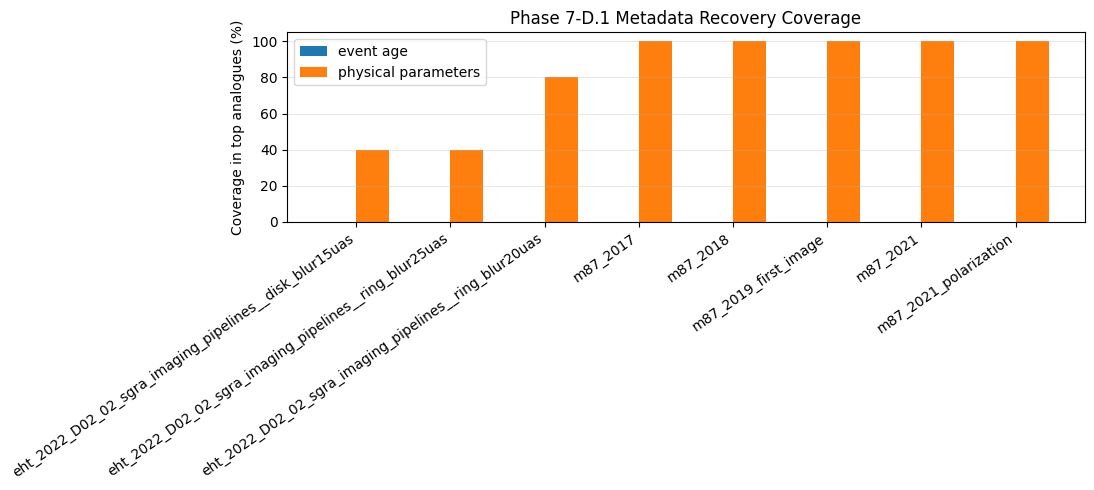

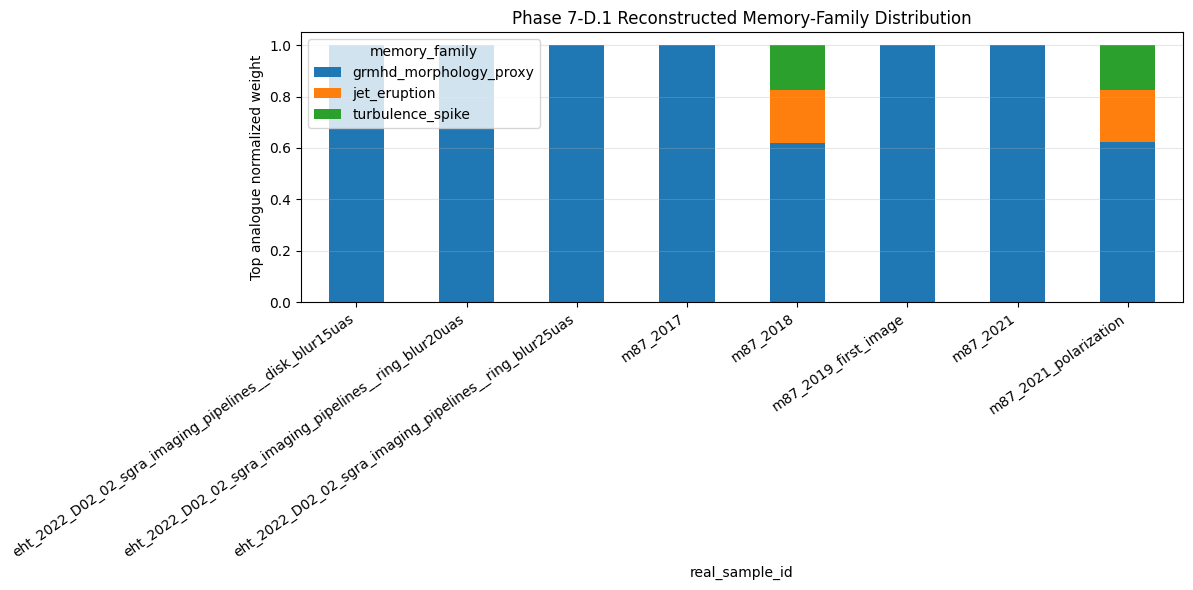

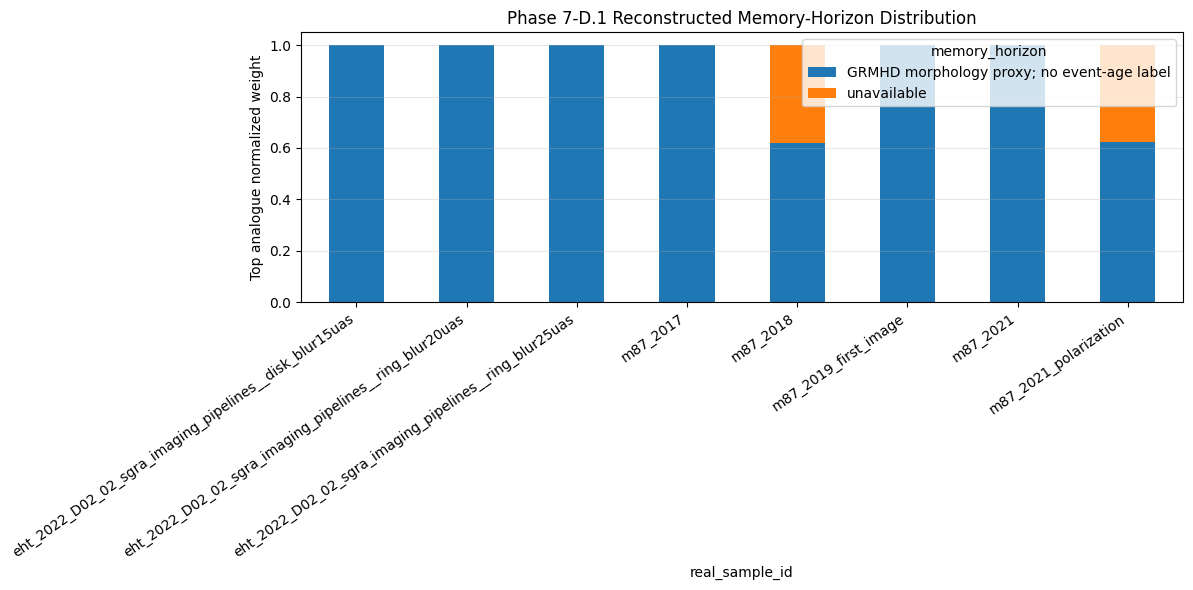

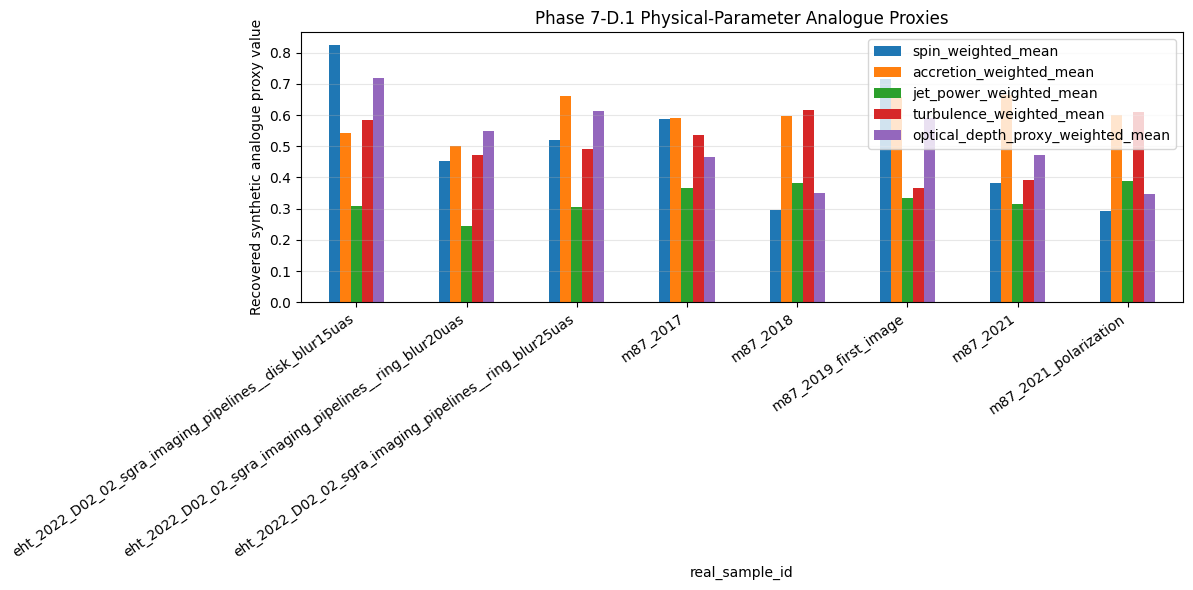

,figure_path
0,/home/marwa/files/phase1_blackhole_generator/o...
1,/home/marwa/files/phase1_blackhole_generator/o...
2,/home/marwa/files/phase1_blackhole_generator/o...
3,/home/marwa/files/phase1_blackhole_generator/o...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_figure_index.csv


In [14]:
# ================================================================
# 14. Figures
# ================================================================

figure_paths = []

# Figure 1: metadata coverage by real observation.
if len(recovery_audit_df):
    plot_df = recovery_audit_df.sort_values("physical_parameter_coverage_percent")
    plt.figure(figsize=(11, 5))
    x = np.arange(len(plot_df))
    width = 0.35
    plt.bar(x - width/2, plot_df["event_age_coverage_percent"].to_numpy(dtype=float), width=width, label="event age")
    plt.bar(x + width/2, plot_df["physical_parameter_coverage_percent"].to_numpy(dtype=float), width=width, label="physical parameters")
    plt.xticks(x, plot_df["real_sample_id"].astype(str).to_numpy(), rotation=35, ha="right")
    plt.ylabel("Coverage in top analogues (%)")
    plt.title("Phase 7-D.1 Metadata Recovery Coverage")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    figure_paths.append(save_plot("phase7D1_metadata_recovery_coverage.png"))

# Figure 2: recovered memory family distribution.
if len(family_reconstructed_df):
    pivot = family_reconstructed_df.pivot_table(index="real_sample_id", columns="memory_family", values="normalized_weight", fill_value=0.0)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_ylabel("Top analogue normalized weight")
    ax.set_title("Phase 7-D.1 Reconstructed Memory-Family Distribution")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")
    figure_paths.append(save_plot("phase7D1_reconstructed_memory_family_distribution.png"))

# Figure 3: recovered memory horizon distribution.
if len(horizon_distribution_df):
    pivot = horizon_distribution_df.pivot_table(index="real_sample_id", columns="memory_horizon", values="normalized_weight", fill_value=0.0)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_ylabel("Top analogue normalized weight")
    ax.set_title("Phase 7-D.1 Reconstructed Memory-Horizon Distribution")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")
    figure_paths.append(save_plot("phase7D1_reconstructed_memory_horizon_distribution.png"))

# Figure 4: selected physical proxies if available.
if len(parameter_reconstructed_df):
    cols = [c for c in parameter_reconstructed_df.columns if c.endswith("_weighted_mean")]
    selected = [c for c in ["spin_weighted_mean", "accretion_weighted_mean", "jet_power_weighted_mean", "turbulence_weighted_mean", "optical_depth_proxy_weighted_mean"] if c in cols]
    if selected:
        plot_df = parameter_reconstructed_df.set_index("real_sample_id")[selected]
        ax = plot_df.plot(kind="bar", figsize=(12, 6))
        ax.set_ylabel("Recovered synthetic analogue proxy value")
        ax.set_title("Phase 7-D.1 Physical-Parameter Analogue Proxies")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=35, ha="right")
        figure_paths.append(save_plot("phase7D1_physical_parameter_proxy_summary.png"))

figure_index_df = pd.DataFrame({"figure_path": [str(p) for p in figure_paths]})
display(figure_index_df)
figure_index_path = save_dataframe(figure_index_df, "phase7D1_figure_index")
print("Saved:", figure_index_path)


In [15]:
# ================================================================
# 15. Copy key Phase 7-D.1 and Phase 7 assets
# ================================================================

key_assets = [
    PHASE7D_DIR / "figures" / "phase7D_dataset_origin_distribution.png",
    PHASE7D_DIR / "figures" / "phase7D_analogue_confidence_scores.png",
    PHASE7D1_FIG_DIR / "phase7D1_metadata_recovery_coverage.png",
    PHASE7D1_FIG_DIR / "phase7D1_reconstructed_memory_family_distribution.png",
    PHASE7D1_FIG_DIR / "phase7D1_reconstructed_memory_horizon_distribution.png",
    PHASE7D1_FIG_DIR / "phase7D1_physical_parameter_proxy_summary.png",
]

copied_rows = []
for src in key_assets:
    dst = copy_if_exists(src, PHASE7D1_ASSET_DIR)
    copied_rows.append({"source": str(src), "copied": dst is not None, "destination": str(dst) if dst is not None else ""})

copied_assets_df = pd.DataFrame(copied_rows)
display(copied_assets_df)
copied_assets_path = save_dataframe(copied_assets_df, "phase7D1_copied_key_assets")
print("Saved:", copied_assets_path)


,source,copied,destination
0,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
1,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
2,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
3,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
4,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
5,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables/phase7D1_copied_key_assets.csv


In [17]:
# ================================================================
# 16. Generate final Phase 7-D.1 report
# ================================================================

created_at = datetime.now().isoformat()

n_real = reconstructed_thesis_df["real_sample_id"].nunique() if len(reconstructed_thesis_df) else 0
n_top = len(top_df)
age_coverage = float(project_recovery_summary_df["event_age_label_coverage_percent_all"].iloc[0]) if len(project_recovery_summary_df) else np.nan
param_coverage = float(project_recovery_summary_df["physical_parameter_coverage_percent_all"].iloc[0]) if len(project_recovery_summary_df) else np.nan

if age_coverage > 0:
    event_age_statement = "Event-age proxies were recovered for at least part of the analogue set."
else:
    event_age_statement = "Event-age labels remain unavailable for the dominant top analogues; this remains a hard limitation."

if param_coverage > 0:
    param_statement = "Physical-parameter proxy summaries were recovered for the analogue set."
else:
    param_statement = "Physical-parameter metadata remains unavailable for the dominant top analogues."

phase7d1_report = f"""
# Phase 7-D.1 Report — Metadata Recovery and Event-Family Reconstruction

Created: {created_at}

## Purpose

Phase 7-D.1 repairs the metadata limitation identified in the final Phase 7 synthesis.
Phase 7-D mapped real EHT observations to calibrated synthetic analogues, but event-age and physical-parameter output tables were empty.
This notebook reconstructs the analogue metadata layer by matching Phase 7-D analogue rows against available metadata tables and phase indexes.

## Inputs

Project root:

{PROJECT_ROOT}

Analogue table:

{phase7D_analogue_path}

Real observations reconstructed:

{n_real}

Top analogue rows used for summaries:

{n_top}

## Metadata Recovery Audit

Project-level recovery:

{df_to_text(project_recovery_summary_df, max_rows=10)}

By real observation:

{df_to_text(recovery_audit_df, max_rows=30)}

## Reconstructed Memory-Family Distributions

{df_to_text(family_reconstructed_df, max_rows=40)}

## Reconstructed Event-Age / Memory-Horizon Summary

{event_age_statement}

Event-age summary:

{df_to_text(age_summary_df, max_rows=30)}

Memory-horizon summary:

{df_to_text(horizon_distribution_df, max_rows=40)}

## Reconstructed Physical-Parameter Proxies

{param_statement}

Physical-parameter summary:

{df_to_text(parameter_reconstructed_df, max_rows=30)}

Magnetic-state summary:

{df_to_text(magnetic_distribution_df, max_rows=30)}

## Thesis-Style Reconstructed Results

{df_to_text(reconstructed_thesis_df, max_rows=30)}

## Before/After Comparison

{df_to_text(before_after_df, max_rows=30)}

## Conservative Interpretation

The reconstructed results should still be interpreted as synthetic analogue summaries, not as recovered real histories.

If event-age coverage remains zero, the correct conclusion is that Phase 7-D can support morphology-family and physical-proxy analogue mapping, but not memory-horizon inference.

If physical-parameter proxy coverage is nonzero, those values should be described as properties of the nearest calibrated synthetic analogues, not measurements of M87* or Sgr A*.

## Recommended Next Step

If event-age labels remain unavailable, the next technical step is to construct a Phase 7A2 metadata schema that explicitly assigns synthetic morphology families, proxy physical states, and optional memory-horizon labels at generation time. Then rerun Phase 7-D and Phase 7-D.1.
"""

report_md_path = PHASE7D1_REPORT_DIR / "phase7D1_metadata_recovery_event_family_reconstruction_report.md"
report_txt_path = PHASE7D1_REPORT_DIR / "phase7D1_metadata_recovery_event_family_reconstruction_report.txt"

with open(report_md_path, "w") as f:
    f.write(phase7d1_report)

with open(report_txt_path, "w") as f:
    f.write(phase7d1_report)

display(Markdown(phase7d1_report[:5000] + "..."))
print("Saved:", report_md_path)
print("Saved:", report_txt_path)



# Phase 7-D.1 Report — Metadata Recovery and Event-Family Reconstruction

Created: 2026-06-19T19:45:00.820659

## Purpose

Phase 7-D.1 repairs the metadata limitation identified in the final Phase 7 synthesis.
Phase 7-D mapped real EHT observations to calibrated synthetic analogues, but event-age and physical-parameter output tables were empty.
This notebook reconstructs the analogue metadata layer by matching Phase 7-D analogue rows against available metadata tables and phase indexes.

## Inputs

Project root:

/home/marwa/files/phase1_blackhole_generator

Analogue table:

/home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/tables/phase7D_calibrated_synthetic_analogues.csv

Real observations reconstructed:

8

Top analogue rows used for summaries:

96

## Metadata Recovery Audit

Project-level recovery:

 n_real_observations  n_analogue_rows  n_top_rows  event_type_label_coverage_percent_all  event_age_label_coverage_percent_all  physical_parameter_coverage_percent_all
                   8              280          96                                  100.0                              0.357143                                93.571429

By real observation:

                                        real_sample_id  n_top_analogues  n_event_type_labels  n_event_age_labels  n_physical_parameter_rows  event_age_coverage_percent  physical_parameter_coverage_percent
eht_2022_D02_02_sgra_imaging_pipelines__disk_blur15uas               10                   10                   0                          4                         0.0                                 40.0
eht_2022_D02_02_sgra_imaging_pipelines__ring_blur20uas               10                   10                   0                          8                         0.0                                 80.0
eht_2022_D02_02_sgra_imaging_pipelines__ring_blur25uas               10                   10                   0                          4                         0.0                                 40.0
                                              m87_2017               10                   10                   0                         10                         0.0                                100.0
                                              m87_2018               18                   18                   0                         18                         0.0                                100.0
                                  m87_2019_first_image               10                   10                   0                         10                         0.0                                100.0
                                              m87_2021               10                   10                   0                         10                         0.0                                100.0
                                 m87_2021_polarization               18                   18                   0                         18                         0.0                                100.0

## Reconstructed Memory-Family Distributions

                                        real_sample_id          memory_family  n_analogues  weight_sum  mean_distance  median_distance  has_true_event_age_fraction  normalized_weight
eht_2022_D02_02_sgra_imaging_pipelines__disk_blur15uas grmhd_morphology_proxy           10    0.520131       2.000434         1.985970                          0.0           1.000000
eht_2022_D02_02_sgra_imaging_pipelines__ring_blur20uas grmhd_morphology_proxy           10    0.469998       2.911781         2.938940                          0.0           1.000000
eht_2022_D02_02_sgra_imaging_pipelines__ring_blur25uas grmhd_morphology_proxy           10    0.506038       2.224467         2.227206                          0.0           1.000000
                                              m87_2017 grmhd_morphology_proxy           10    0.555053       1.270548         1.361271                          0.0           1.000000
                                              m87_2018 grmhd_morphology_proxy            6    0.553849       0.892570         0.945704                          0.0           0.618345
                                              m87_2018           jet_eruption            6    0.185335       2.643533         2.643533                          0.0           0.206918
                                              m87_2018       turbulence_spike            6    0.156512       3.071881         3.071881                          0.0           0.174738
                                  m87_2019_first_image grmhd_morphology_proxy           10    0.650483       1.395680         1.332349                          0.0           1.000000
                                              m87_2021 grmhd_morphology_proxy           10    0.650578       0.999895         1.099015                          0.0           1.000000
                                 m87_2021_polarization grmhd_morph...

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/reports/phase7D1_metadata_recovery_event_family_reconstruction_report.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/reports/phase7D1_metadata_recovery_event_family_reconstruction_report.txt


In [18]:
# ================================================================
# 17. Final index
# ================================================================

phase7d1_index = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "phase7D1_dir": str(PHASE7D1_DIR),
    "input_phase7D_analogue_table": str(phase7D_analogue_path),
    "bridge_dataset": BRIDGE_DATASET,
    "top_k_for_summary": int(TOP_K_FOR_SUMMARY),
    "n_real_observations": int(n_real),
    "n_top_analogue_rows": int(n_top),
    "event_age_coverage_percent_all": age_coverage,
    "physical_parameter_coverage_percent_all": param_coverage,
    "main_outputs": {
        "metadata_source_audit": str(metadata_audit_path),
        "alias_audit": str(alias_audit_path),
        "raw_recovered_analogues": str(recovered_raw_path),
        "canonical_recovered_analogues": str(canonical_path),
        "project_recovery_summary": str(project_recovery_path),
        "recovery_audit_by_real_observation": str(recovery_audit_path),
        "memory_family_distribution": str(family_reconstructed_path),
        "event_age_summary": str(age_summary_path),
        "memory_horizon_distribution": str(horizon_distribution_path),
        "physical_parameter_summary": str(parameter_reconstructed_path),
        "magnetic_state_distribution": str(magnetic_distribution_path),
        "thesis_style_reconstructed_results": str(reconstructed_thesis_path),
        "before_after_comparison": str(before_after_path),
        "figure_index": str(figure_index_path),
        "copied_assets": str(copied_assets_path),
        "report_md": str(report_md_path),
        "report_txt": str(report_txt_path),
    },
    "figures": [str(p) for p in figure_paths],
}

index_path = PHASE7D1_DIR / "phase7D1_index.json"
with open(index_path, "w") as f:
    json.dump(phase7d1_index, f, indent=2)

print("=" * 80)
print("Phase 7-D.1 complete")
print("=" * 80)
print("Index:", index_path)
print("Output directory:", PHASE7D1_DIR)
print("Tables:", PHASE7D1_TABLE_DIR)
print("Figures:", PHASE7D1_FIG_DIR)
print("Reports:", PHASE7D1_REPORT_DIR)
print("Event-age coverage:", age_coverage)
print("Physical-parameter coverage:", param_coverage)
print("=" * 80)


Phase 7-D.1 complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/phase7D1_index.json
Output directory: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/reports
Event-age coverage: 0.35714285714285715
Physical-parameter coverage: 93.57142857142857


Real EHT observations consistently align with a GRMHD-inspired synthetic bridge domain. This relationship survives calibration and robustness testing. Calibrated analogue mapping recovers morphology-family and physical-state proxy distributions, but does not yet support reliable memory-horizon reconstruction.